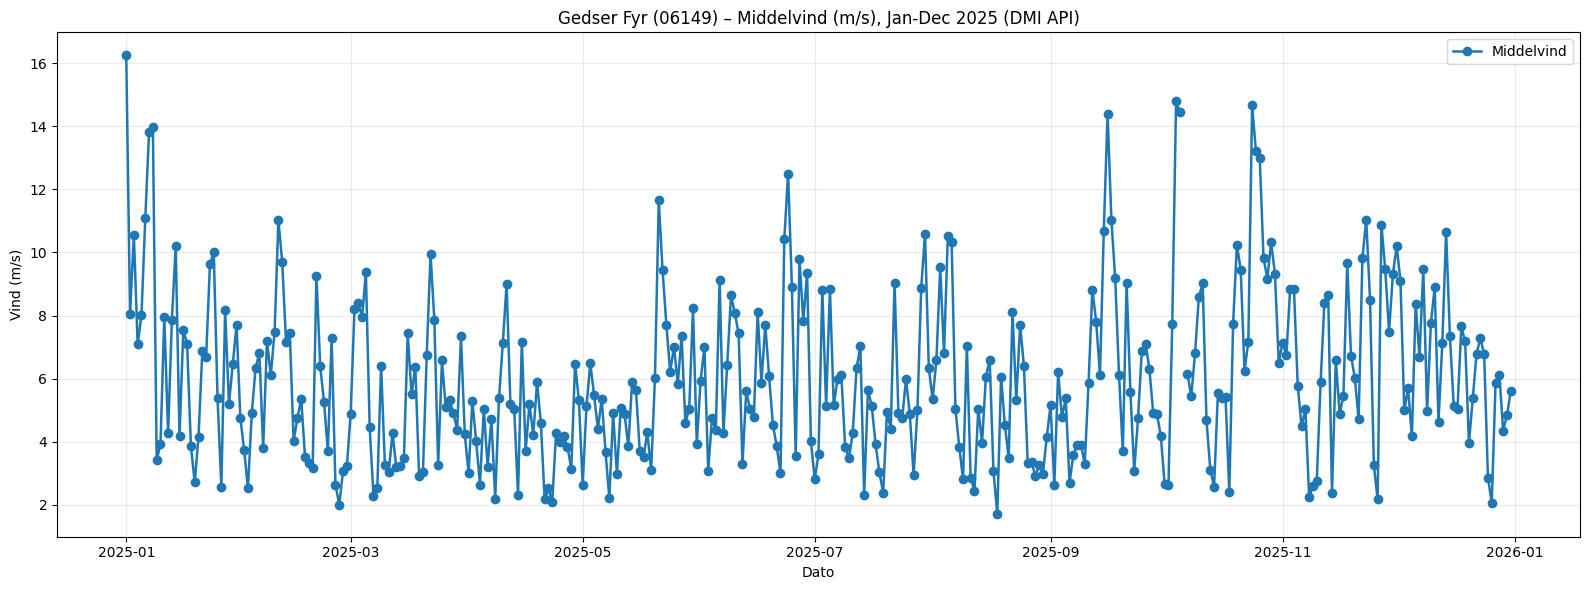

Station used: Gedser Fyr (06149)
Parameter used: wind_speed


,Middelvind
2025-01-01 00:00:00+00:00,16.251049
2025-01-02 00:00:00+00:00,8.048951
2025-01-03 00:00:00+00:00,10.567361
2025-01-04 00:00:00+00:00,7.086111
2025-01-05 00:00:00+00:00,8.006250


In [6]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_BASE = "https://opendataapi.dmi.dk/v2/metObs"
API_KEY = os.getenv("DMI_API_KEY", "")
STATION_ID = os.getenv("DMI_STATION_ID", "06149")
PARAMETER_ID = "wind_speed"  # Middelvind
DATE_FROM = "2025-01-01T00:00:00Z"
DATE_TO = "2025-12-31T23:59:59Z"
DATE_RANGE = f"{DATE_FROM}/{DATE_TO}"


def dmi_get(path: str, params: dict) -> dict:
    url = f"{API_BASE}{path}"
    request_params = dict(params)
    if API_KEY:
        request_params["api-key"] = API_KEY

    response = requests.get(url, params=request_params, timeout=45)
    response.raise_for_status()
    return response.json()


# Resolve station name for title
station_payload = dmi_get(
    "/collections/station/items",
    {
        "stationId": STATION_ID,
        "limit": 1,
    },
)
station_features = station_payload.get("features", [])
station_name = STATION_ID
if station_features:
    station_name = station_features[0].get("properties", {}).get("name", STATION_ID)

# Fetch wind speed observations (Middelvind)
obs_payload = dmi_get(
    "/collections/observation/items",
    {
        "stationId": STATION_ID,
        "parameterId": PARAMETER_ID,
        "datetime": DATE_RANGE,
        "limit": 300000,
    },
)

rows = []
for feature in obs_payload.get("features", []):
    props = feature.get("properties", {})
    observed = props.get("observed")
    value = props.get("value")
    if observed is None or value is None:
        continue
    rows.append((pd.to_datetime(observed, utc=True), float(value)))

if not rows:
    raise RuntimeError(
        f"No wind_speed data found for station {STATION_ID} in {DATE_RANGE}. "
        "Try another station by setting DMI_STATION_ID."
    )

wind_speed_series = pd.Series(
    [value for _, value in rows],
    index=[timestamp for timestamp, _ in rows],
).sort_index()

# Aggregate to daily mean values
start = pd.Timestamp("2025-01-01", tz="UTC")
end = pd.Timestamp("2025-12-31", tz="UTC")
all_days = pd.date_range(start, end, freq="D")

df = pd.DataFrame(index=all_days)
df["Middelvind"] = wind_speed_series.resample("D").mean()

if df["Middelvind"].dropna().empty:
    raise RuntimeError("No plottable daily wind_speed values were returned from DMI for this station.")

# Plot Middelvind only
plt.figure(figsize=(16, 6))
plt.plot(df.index, df["Middelvind"], marker="o", linewidth=1.8, label="Middelvind")

plt.title(f"{station_name} ({STATION_ID}) – Middelvind (m/s), Jan-Dec 2025 (DMI API)")
plt.ylabel("Vind (m/s)")
plt.xlabel("Dato")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Station used: {station_name} ({STATION_ID})")
print(f"Parameter used: {PARAMETER_ID}")

df.head()

In [7]:
import pandas as pd

# Calculate Windturbine_Produced from Cell 1 output (df['Middelvind'])
C = 0.4

windturbine_daily_df = df[["Middelvind"]].copy()

# Same formula basis as your simulation definitions
# Wind_Power(v) = 19232.5 * v^3 / 1000  (kW)
# Windturbine_Produced(v) = C * Wind_Power(v)
windturbine_daily_df["Wind_Power_kW"] = 19232.5 * (windturbine_daily_df["Middelvind"] ** 3) / 1000
windturbine_daily_df["Windturbine_Produced"] = C * windturbine_daily_df["Wind_Power_kW"]

# Keep only days where Middelvind exists
windturbine_daily_df = windturbine_daily_df.dropna(subset=["Middelvind"])

Windturbine_Produced_Yearly = float(windturbine_daily_df["Windturbine_Produced"].sum())

print(f"Windturbine_Produced_Yearly: {Windturbine_Produced_Yearly:,.2f}")
windturbine_daily_df.head()

Windturbine_Produced_Yearly: 1,002,283.19


,Middelvind,Wind_Power_kW,Windturbine_Produced
2025-01-01 00:00:00+00:00,16.251049,82542.940591,33017.176237
2025-01-02 00:00:00+00:00,8.048951,10028.906898,4011.562759
2025-01-03 00:00:00+00:00,10.567361,22695.271718,9078.108687
2025-01-04 00:00:00+00:00,7.086111,6843.206015,2737.282406
2025-01-05 00:00:00+00:00,8.006250,9870.137035,3948.054814


In [8]:
import time
from IPython.display import clear_output

# 1 simulation day = 1 second
SECONDS_PER_DAY = 1.0

loop_df = df.loc["2025-01-01":"2025-12-31", ["Middelvind"]].copy()

if loop_df["Middelvind"].dropna().empty:
    raise RuntimeError("No Middelvind data available for 2025.")


def wind_speed_for_day(day):
    value = loop_df.loc[day, "Middelvind"]
    if pd.isna(value):
        return None
    return float(value)


# Definitions for later simulation use (kW)
C = 0.4


def Wind_Power(v):
    if v is None:
        return None
    return 19232.5 * (v ** 3) / 1000 # Convert to kW


def Windturbine_Produced(v):
    wind_power = Wind_Power(v)
    if wind_power is None:
        return None
    return C * wind_power


print("Starting 2025 wind_speed playback (1 day = 1 second)...")

try:
    for current_date in loop_df.index:
        wind_speed = wind_speed_for_day(current_date)

        if wind_speed is None:
            display_text = f"Date: {current_date.strftime('%Y-%m-%d')} | wind_speed (Middelvind): no data"
        else:
            display_text = (
                f"Date: {current_date.strftime('%Y-%m-%d')} | "
                f"wind_speed (Middelvind): {wind_speed:.2f} m/s"
            )

        clear_output(wait=True)
        print(display_text)
        time.sleep(SECONDS_PER_DAY)

    clear_output(wait=True)
    print("Playback complete for 2025.")
except KeyboardInterrupt:
    clear_output(wait=True)
    print("Playback stopped by user.")

Playback stopped by user.


In [9]:
print(Windturbine_Produced(11.8))

12639.845176000004


In [10]:
# Fixed yearly total (kWh) from the previous calculation
Windturbine_Produced_Yearly = 24054796.56

Windturbine_Produced_Yearly

24054796.56